## 1. Purpose

This notebook analyzes the Exponential distribution in the context of reliability engineering.

The objective is to:
- Model time to failure for systems with a constant failure rate
- Compute reliability metrics such as PDF, CDF, and MTTF
- Understand its role as a special case of the Weibull distribution

The Exponential distribution is widely used for components that do not age, i.e., whose failure rate is constant over time.

## 2. Mathematical Model

The Exponential distribution is defined by the failure rate parameter $\lambda > 0$.

The probability density function (PDF) is:

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

The cumulative distribution function (CDF) is:

$$
F(x) = P(X \le x) = 1 - e^{-\lambda x}
$$

The reliability function is:

$$
R(x) = P(X > x) = e^{-\lambda x}
$$

The mean time to failure (MTTF) is:

$$
\text{MTTF} = \frac{1}{\lambda}
$$

The hazard rate is constant:

$$
h(x) = \lambda
$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
lambda_ = 0.001  # failure rate

# Functions
def exp_pdf(x, lambda_):
    return lambda_ * np.exp(-lambda_ * x)

def exp_cdf(x, lambda_):
    return 1 - np.exp(-lambda_ * x)

def exp_reliability(x, lambda_):
    return np.exp(-lambda_ * x)

def exp_mttf(lambda_):
    return 1 / lambda_

def exp_hazard(x, lambda_):
    return lambda_  # constant

# Example
x_value = 500
prob = exp_cdf(x_value, lambda_)

print(f"P(X < {x_value}) = {prob:.5f}")
print(f"MTTF = {exp_mttf(lambda_):.2f}")

P(X < 500) = 0.39347
MTTF = 1000.00


# Exercises

## Exercise 3.4
Assume that 100 components are placed on test for 1000 h. From previous testing, we 
believe that the hazard rate is constant, and the $MTTF = 500$ h. Estimate the number of 
components that will fail in the time interval of 100–200 h. How many components will 
fail if it is known that 15 components failed in $T < 100$ h?

In [12]:
# For number of components, between 100 and 200 h
# P(X < 100) and P(X < 200) 
# Subtract to get P(100 < X < 200) = P(X < 200) - P(X < 100)

# lambda is reserve word in Python, so we use lambda_ instead of lambda
MTTF = 500
lambda_ = 1 / MTTF
number_components = 100

P_less_100 = exp_cdf(100, lambda_)
P_less_200 = exp_cdf(200, lambda_)
P_between_100_200 = P_less_200 - P_less_100

# Total number of failures rounded up to next integer
total_failures = np.ceil(number_components * P_between_100_200)

print(f"Number of failures between 100 and 200 hours: {total_failures:.0f}")

Number of failures between 100 and 200 hours: 15


If 15 units fail before 100 hours, then there 85 components at the start of 100th hour. **HOWEVER**, as exponential is memoryless, if 85 survived the first 100 h, the next 100 hours (the interval 100-200h) is akin to surviving for the next 100 hours from birth. Thus:

$$
P(T < 100) = 1 - e^{-\lambda t} = 1 - e^{-0.2} = 0.1813
$$

In [15]:
# Parameters
remaining_components = number_components - 15
P_100_hours = exp_cdf(100, lambda_)
remaining_failures = np.ceil(remaining_components * P_100_hours)

print(f"Likelihood of failure within 100 hours for remaining components: {P_100_hours:.4f}")
print(f"Number of failures between 100 and 200 hours after 15 failures: {remaining_failures:.0f}")

Likelihood of failure within 100 hours for remaining components: 0.1813
Number of failures between 100 and 200 hours after 15 failures: 16


# Plotting Method

$$
ln(R(t)) = -\lambda t
$$

## Example 3.8

Nine times to failure of a diesel generator are recorded as 31.3, 45.9, 78.3, 22.1, 2.3, 4.8, 8.1, 11.3, 
and 17.3 days. If the diesel is restored to as good as new after each failure, determine whether the 
data represent the exponential distribution. That is, find $\hat{\lambda}$ and $\hat{R}$ (193 h).

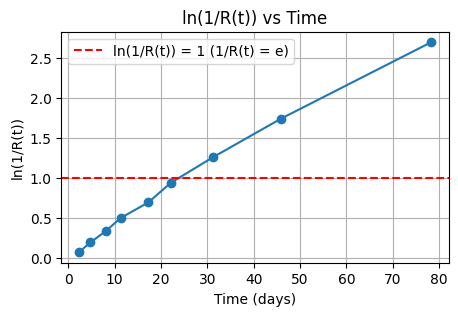

,index,Failure Time (days),Reliability R(t),1/R(t),ln(1/R(t))
0,1,2.3,0.932432,1.072464,0.069959
1,2,4.8,0.824324,1.213115,0.193191
2,3,8.1,0.716216,1.396226,0.333773
3,4,11.3,0.608108,1.644444,0.497403
4,5,17.3,0.500000,2.000000,0.693147
5,6,22.1,0.391892,2.551724,0.936769
6,7,31.3,0.283784,3.523810,1.259543
7,8,45.9,0.175676,5.692308,1.739116
8,9,78.3,0.067568,14.800000,2.694627


In [20]:
# Minimum imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Solution - Example 3.8

rt_regular = lambda n, i: (n - i + 0.625) / (n + 0.25)
rt_inverse = lambda n, i: 1/rt_regular(n, i)

failures_days = np.sort(np.array([31.3, 45.9, 78.3, 22.1, 2.3, 4.8, 8.1, 11.3, 17.3]))
i = np.arange(1, len(failures_days) + 1)
n = len(failures_days)
reliability = rt_regular(n, i)
inverse_reliability = rt_inverse(n, i)

ln_inverse_reliability = np.log(inverse_reliability)


plt.figure(figsize=(5, 3))
plt.plot(failures_days, ln_inverse_reliability, marker='o', linestyle='-')
plt.title('ln(1/R(t)) vs Time')
plt.xlabel('Time (days)')
plt.ylabel('ln(1/R(t))')
# Crossing point equivalent to MTTF can be estimated by finding where ln(1/R(t)) = 0, which corresponds to R(t) = 1.
plt.axhline(1, color='red', linestyle='--', label='ln(1/R(t)) = 1 (1/R(t) = e)')
plt.legend()
plt.grid()
plt.show()

# Dataframe ajusts
df_example_3_8 = pd.DataFrame({
    'index': i,
    'Failure Time (days)': failures_days,
    'Reliability R(t)': reliability,
    '1/R(t)': inverse_reliability,
    'ln(1/R(t))': ln_inverse_reliability
})

df_example_3_8


By evaluating the red-line, we can check that it crosses about time (in days) around 24 days. Thus $\hat{\MTTF} \approx 24$.

As $MTTF = \frac{1}{\lambda}$ then, $\hat{\lambda} = 1/24 = 0.4167$ failures per day

As the next question is R(193), i.e., reliability at 193 hours, we need to convert from days to hours.

In [15]:
# Solution - Example 3.8 continuation

example_3_8_lambda_hat_days = 1/24
example_3_8_lambda_hat_hours = (1 / 24) / 24  # convert to hours, about 1.736e-3
Reliability_hat_193_hours = np.exp(-example_3_8_lambda_hat_hours * 193)

print(f"Estimated Reliability at 193 hours: {Reliability_hat_193_hours:.2f}")

Estimated Reliability at 193 hours: 0.72


## Exercise 3.11

A test was run on 10 electric motors under high temperature. The test was run for 60 h, 
during which six motors failed. The failures occurred at the following times: 37.5, 46.0, 
48.0, 51.5, 53.0, and 54.5 h. We do not know whether an exponential distribution or a 
Weibull distribution model is better for representing these data. Use the plotting method as 
the main tool to discuss the appropriateness of these two models.


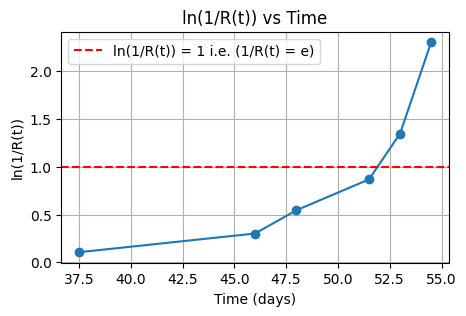

,index,Failure Time (days),Reliability R(t),1/R(t),ln(1/R(t))
0,1,37.5,0.90,1.111111,0.105361
1,2,46.0,0.74,1.351351,0.301105
2,3,48.0,0.58,1.724138,0.544727
3,4,51.5,0.42,2.380952,0.867501
4,5,53.0,0.26,3.846154,1.347074
5,6,54.5,0.10,10.000000,2.302585


In [25]:
## Exercise 3.11

# Minimum imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Solution - Example 3.11

rt_regular = lambda n, i: (n - i + 0.625) / (n + 0.25)
rt_inverse = lambda n, i: 1/rt_regular(n, i)

failures_days = np.sort(np.array([37.5, 46.0, 48.0, 51.5, 53.0, 54.5]))
i = np.arange(1, len(failures_days) + 1)
n = len(failures_days)
reliability = rt_regular(n, i)
inverse_reliability = rt_inverse(n, i)

ln_inverse_reliability = np.log(inverse_reliability)


plt.figure(figsize=(5, 3))
plt.plot(failures_days, ln_inverse_reliability, marker='o', linestyle='-')
plt.title('ln(1/R(t)) vs Time')
plt.xlabel('Time (days)')
plt.ylabel('ln(1/R(t))')
# Crossing point equivalent to MTTF can be estimated by finding where ln(1/R(t)) = 0, which corresponds to R(t) = 1.
plt.axhline(1, color='red', linestyle='--', label='ln(1/R(t)) = 1 i.e. (1/R(t) = e)')
plt.legend()
plt.grid()
plt.show()

# Dataframe ajusts
df_example_3_11 = pd.DataFrame({
    'index': i,
    'Failure Time (days)': failures_days,
    'Reliability R(t)': reliability,
    '1/R(t)': inverse_reliability,
    'ln(1/R(t))': ln_inverse_reliability
})

df_example_3_11


From the graphic one can note that it does not form a line, therefore, exponential is not a good fit for this case. Thus, we should proceed to Weibull plotting.

$$
ln\left [ ln \left ( \frac{1}{R(t)} \right ) \right ]=\beta ln(t) - \beta ln(\alpha)
$$

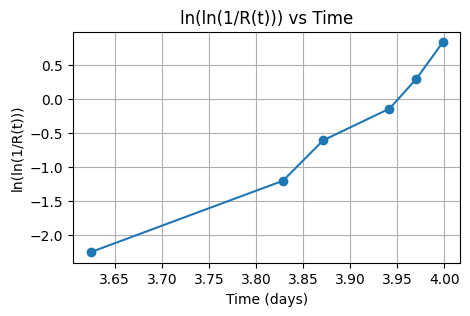

Slope: 7.85586085554573
Intercept: -30.93223360471706
R^2: 0.945958147300884
Estimated Weibull parameters: alpha = 51.29, beta = 7.86


,index,Failure Time (days),Reliability R(t),1/R(t),ln(1/R(t)),ln(ln(1/R(t))),ln(time)
0,1,37.5,0.90,1.111111,0.105361,-2.250367,3.624341
1,2,46.0,0.74,1.351351,0.301105,-1.200296,3.828641
2,3,48.0,0.58,1.724138,0.544727,-0.607470,3.871201
3,4,51.5,0.42,2.380952,0.867501,-0.142139,3.941582
4,5,53.0,0.26,3.846154,1.347074,0.297935,3.970292
5,6,54.5,0.10,10.000000,2.302585,0.834032,3.998201


In [26]:
ln_ln_inverse_reliability = np.log(ln_inverse_reliability)

df_example_3_11['ln(ln(1/R(t)))'] = ln_ln_inverse_reliability
df_example_3_11['ln(time)'] = np.log(df_example_3_11['Failure Time (days)'])

plt.figure(figsize=(5, 3))
plt.plot(df_example_3_11['ln(time)'], df_example_3_11['ln(ln(1/R(t)))'], marker='o', linestyle='-')
plt.title('ln(ln(1/R(t))) vs Time')
plt.xlabel('Time (days)')
plt.ylabel('ln(ln(1/R(t)))')
plt.grid()
plt.show()

# Linear regression to estimate parameters of Weibull distribution
from scipy.stats import linregress

x = np.log(df_example_3_11['Failure Time (days)'])
y = ln_ln_inverse_reliability
result = linregress(x, y)

print(f"Slope: {result.slope}")
print(f"Intercept: {result.intercept}")
print(f"R^2: {result.rvalue**2}")

# Calculating approximate \alpha and \beta parameters of Weibull distribution
beta_example_3_11 = result.slope
alpha_example_3_11 = np.exp(-result.intercept / beta_example_3_11)
print(f"Estimated Weibull parameters: alpha = {alpha_example_3_11:.2f}, beta = {beta_example_3_11:.2f}")

df_example_3_11